In [1]:
import os
from fair import FAIR
from fair.io import read_properties
from fair.interface import initialise
from fair.structure.units import desired_emissions_units
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import xarray as xr
from pathlib import Path
import glob
from drawdown import DATA_DIR
import string
import pandas as pd
import datetime
from utils import zenodo, CEDS
from drawdown import explorer

In [16]:
for_talk=False
if for_talk:
    import mplcyberpunk

    plt.style.use("cyberpunk")
    default_figsize=(13.33, 7.5)
else:
    plt.style.use("default")
    default_figsize=(6.4,4.8)

# The TLC framework
It really matters where you target electricity sector solutions.  The electric grid is not the same in all regions.  Let's look at emissions in India, China, and the USA.

In [10]:
india_emissions=CEDS.electricity_all_species("ind")
china_emissions=CEDS.electricity_all_species("chn")
usa_emissions=CEDS.electricity_all_species("usa")

## CO2 emissions
US CO2 emissions have been historically high but are falling.  China now emits about 2x as much and still rising.  India emits less than China but still rising.

Text(0, 0.5, 'Mt CO2')

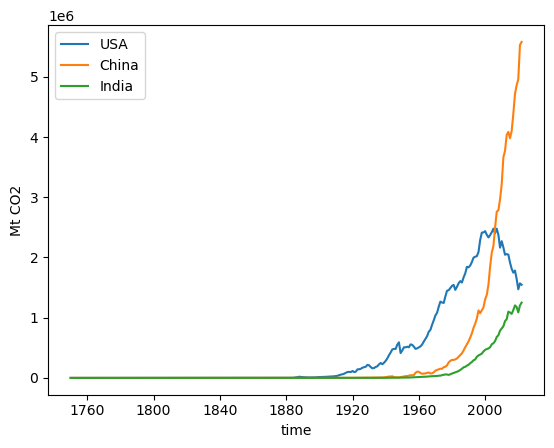

In [18]:
plt.figure(figsize=default_figsize)
usa_emissions["CO2"].plot(label="USA")
china_emissions["CO2"].plot(label="China")
india_emissions["CO2"].plot(label="India")
plt.legend()
plt.ylabel("Mt CO2")

### Methane
Methane emissions from electricity generation are generally much smaller, but China CH4 emissions are large due to the enormous reliance on coal.

Text(0, 0.5, 'Mt CH4')

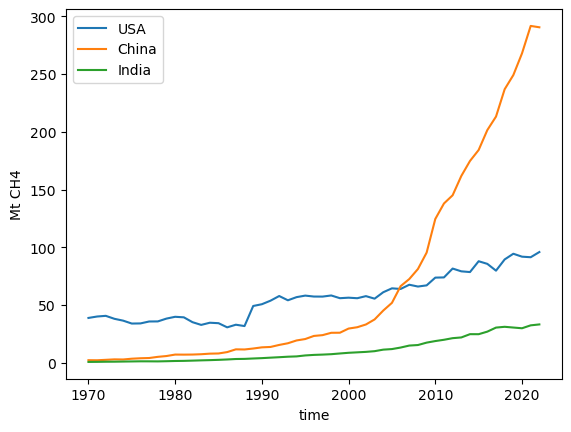

In [21]:
plt.figure(figsize=default_figsize)
usa_emissions["CH4"].plot(label="USA")
china_emissions["CH4"].plot(label="China")
india_emissions["CH4"].plot(label="India")
plt.legend()
plt.ylabel("Mt CH4")

### SO2
The Clean Air Act in 1970 substantially cleaned up US air.  More recent action in China has led to an even more dramatic fall in sulfate pollution- even though they still have a lot of coal plants, they put scrubbers on them.  Meanwhile the Indian electric grid is still very polluting.

Text(0, 0.5, 'Mt SO2')

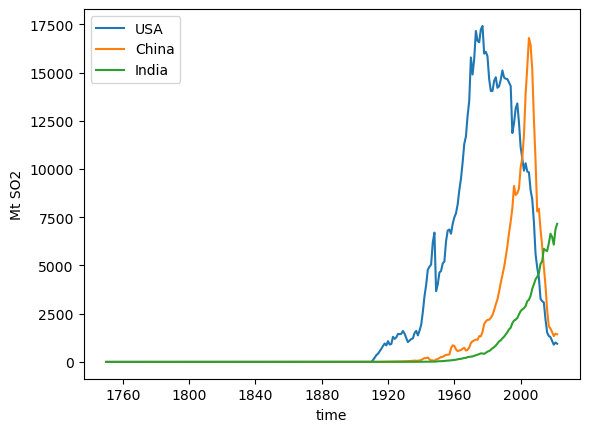

In [23]:
plt.figure(figsize=default_figsize)
usa_emissions["SO2"].plot(label="USA")
china_emissions["SO2"].plot(label="China")
india_emissions["SO2"].plot(label="India")
plt.legend()
plt.ylabel("Mt SO2")

# What if we were to magically replace a country's entire electric sector with renewables?
Use the `explorer.drawdown_model` tool to explore the consequences of immediately transitioning each country to a completely renewable grid.

In [24]:

labels=["India","China","USA"]
i=0
perturbation_dicts={}
for d in [india_emissions,china_emissions,usa_emissions]:
    faird={}
    fair_start_time = 1750
    fair_end_time = 2101
    timepoints = np.arange(fair_start_time,fair_end_time+1,1)
    for k,v in d.items():
        faird=faird | CEDS.CEDS_to_FAIR(
            explorer.step_function(timepoints,2030,-v.values[-1]),
            str(k))
    perturbation_dicts[labels[i]]=faird
    i+=1

In [25]:
elec_model=explorer.drawdown_model("constant",perturbation_dicts=perturbation_dicts,lite=True,n_lite=5)

Running 40 projections in parallel:   0%|          | 0/352 [00:00<?, ?timesteps/s]

## USA
If we replace the entire US electric grid with renewables, we'd see a reducting of warming (about 35 millidegrees by the end of the century).  We'd see a very small short-term warming effect due to the removal of SO2 and NOx pollution.

Text(0.5, 1.0, 'Warming avoided by replacing entire national power sector with renewables')

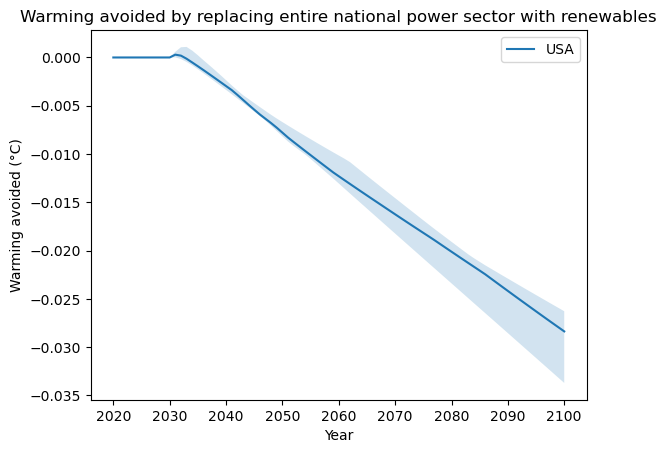

In [31]:
explorer.plot_T_diff(elec_model,scenarios=["USA"])
plt.title("Warming avoided by replacing entire national power sector with renewables")

## China
And same for China- we could prevent more than a tenth of a degree of warming by cleaning up its electricity sector.

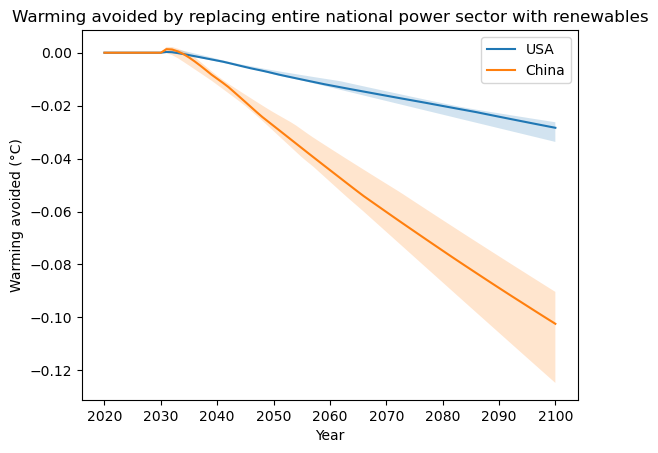

In [32]:
plt.title("Warming avoided by replacing entire national power sector with renewables")
explorer.plot_T_diff(elec_model,scenarios=["USA","China"])

## India
But because the Indian electricity grid is relatively small (so doesn't emit that much CO2, globally speaking) but filthy, replacing the whole thing wiht renewables would lead to a small *warming* effect

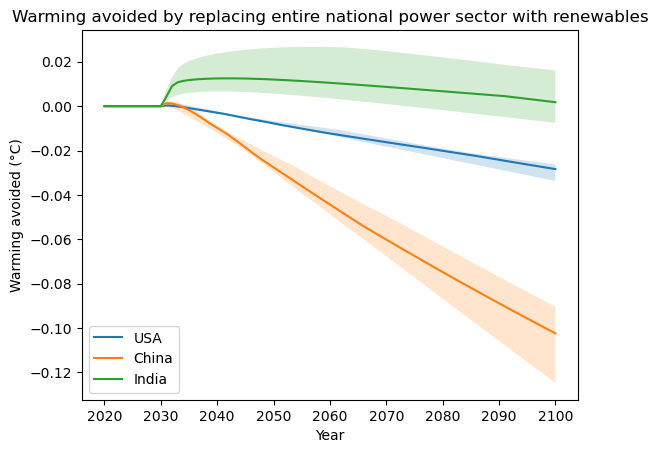

In [33]:
plt.title("Warming avoided by replacing entire national power sector with renewables")
explorer.plot_T_diff(elec_model,scenarios=["USA","China","India"])

# So should we avoid cleaning up India's power sector?
No! This is where *cobenefits* come in.